In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [5]:
df = sns.load_dataset('car_crashes')

## Basic Info about the dataset

In [7]:
df.head(10)

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA
5,13.6,5.032,3.808,10.744,12.920,835.50,139.91,CO
6,10.8,4.968,3.888,9.396,8.856,1068.73,167.02,CT
7,16.2,6.156,4.860,14.094,16.038,1137.87,151.48,DE
8,5.9,2.006,1.593,5.900,5.900,1273.89,136.05,DC
9,17.9,3.759,5.191,16.468,16.826,1160.13,144.18,FL


In [9]:
df.shape

(51, 8)

In [11]:
df.columns

Index(['total', 'speeding', 'alcohol', 'not_distracted', 'no_previous',
       'ins_premium', 'ins_losses', 'abbrev'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   total           51 non-null     float64
 1   speeding        51 non-null     float64
 2   alcohol         51 non-null     float64
 3   not_distracted  51 non-null     float64
 4   no_previous     51 non-null     float64
 5   ins_premium     51 non-null     float64
 6   ins_losses      51 non-null     float64
 7   abbrev          51 non-null     object 
dtypes: float64(7), object(1)
memory usage: 3.3+ KB


#### The dataset contains 7 numerical columns and 1 object type column

## Statistical Summary

In [15]:
df.describe()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,15.790196,4.998196,4.886784,13.573176,14.004882,886.957647,134.493137
std,4.122002,2.017747,1.729133,4.508977,3.764672,178.296285,24.835922
min,5.900000,1.792000,1.593000,1.760000,5.900000,641.960000,82.750000
25%,12.750000,3.766500,3.894000,10.478000,11.348000,768.430000,114.645000
50%,15.600000,4.608000,4.554000,13.857000,13.775000,858.970000,136.050000
75%,18.500000,6.439000,5.604000,16.140000,16.755000,1007.945000,151.870000
max,23.900000,9.450000,10.038000,23.661000,21.280000,1301.520000,194.780000


## Data Cleaning

### Checking for null values

In [17]:
df.isna().sum()

total             0
speeding          0
alcohol           0
not_distracted    0
no_previous       0
ins_premium       0
ins_losses        0
abbrev            0
dtype: int64

#### The dataset does not contain any null values.

### Checking for duplicated values

In [19]:
df.duplicated().sum()

0

#### The dataset does not contain any duplicated values as well.

### Detecting outliers

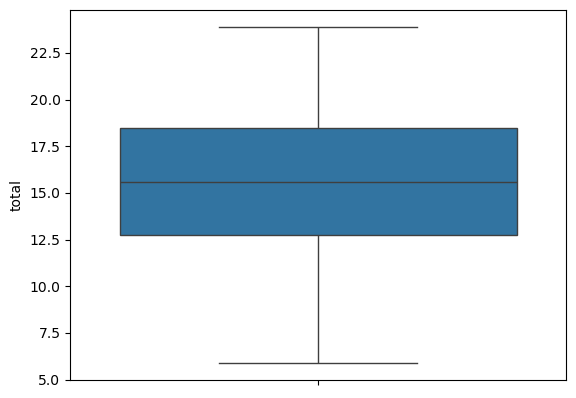

In [21]:
sns.boxplot(y='total',data=df)
plt.show()

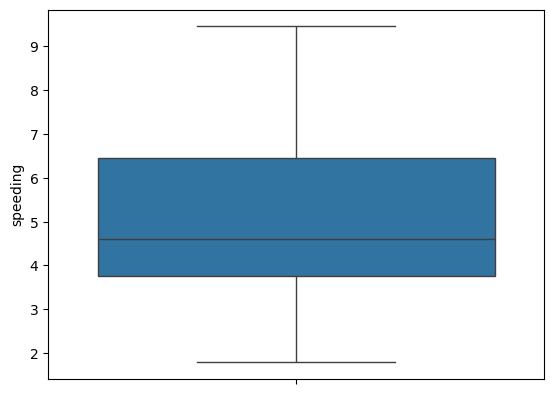

In [23]:
sns.boxplot(y='speeding',data=df)
plt.show()

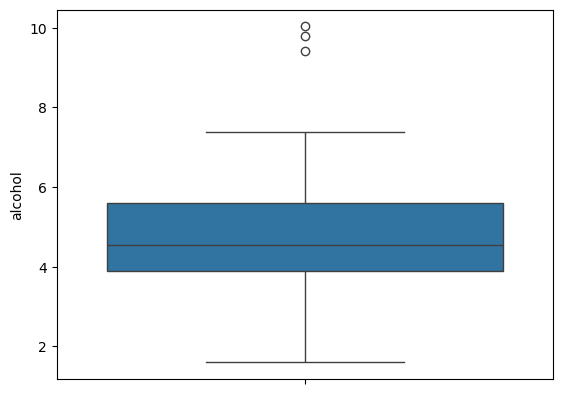

In [25]:
sns.boxplot(y='alcohol',data=df)
plt.show()

In [27]:
df.alcohol.describe()

count    51.000000
mean      4.886784
std       1.729133
min       1.593000
25%       3.894000
50%       4.554000
75%       5.604000
max      10.038000
Name: alcohol, dtype: float64

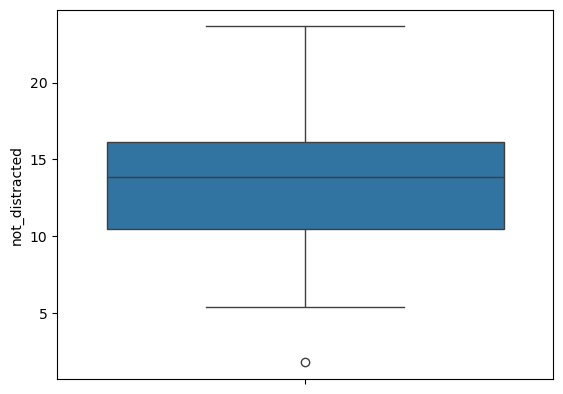

In [29]:
sns.boxplot(y='not_distracted',data=df)
plt.show()

In [31]:
df.not_distracted.describe()

count    51.000000
mean     13.573176
std       4.508977
min       1.760000
25%      10.478000
50%      13.857000
75%      16.140000
max      23.661000
Name: not_distracted, dtype: float64

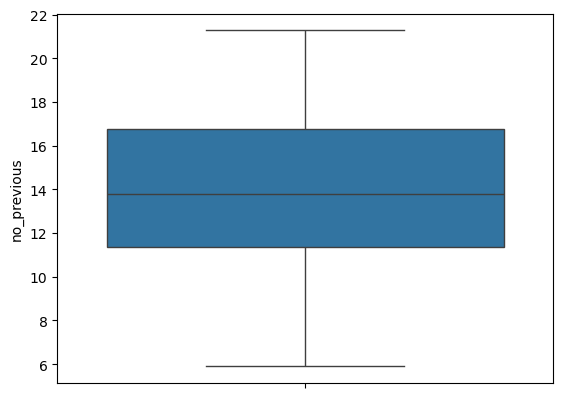

In [33]:
sns.boxplot(y='no_previous',data=df)
plt.show()

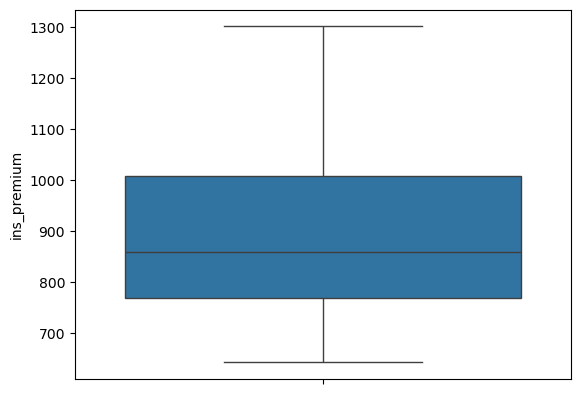

In [35]:
sns.boxplot(y='ins_premium',data=df)
plt.show()

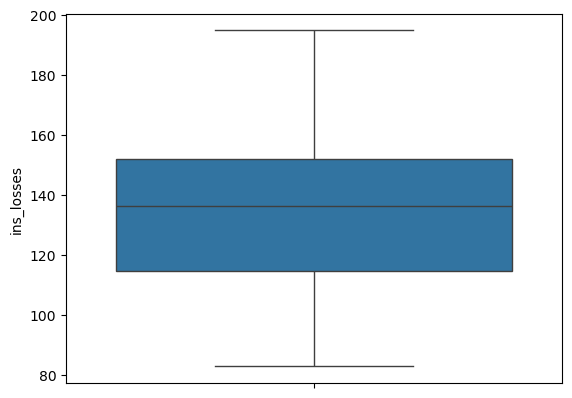

In [37]:
sns.boxplot(y='ins_losses',data=df)
plt.show()

#### Only 2 columns contain outliers: 'alcohol' and 'not_distracted'

## Removing Outliers using IQR Method

In [39]:
# User defined function to remove outliers
def outlier(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3-Q1
    Upper_Bound = Q3 + 1.5*IQR
    Lower_Bound = Q1 - 1.5*IQR
    return data.clip(Upper_Bound,Lower_Bound)
    

In [41]:
df['Alcohol'] = outlier(df.alcohol)

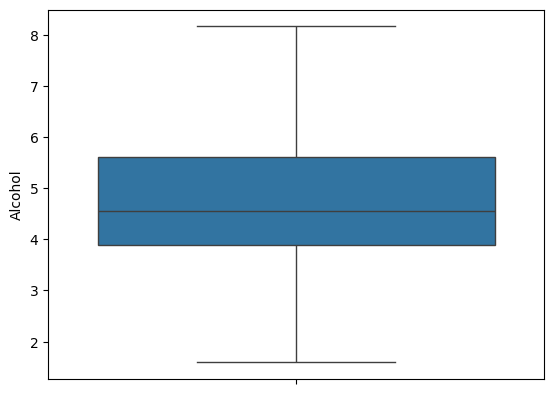

In [43]:
sns.boxplot(y='Alcohol',data=df)
plt.show()

In [45]:
df['Not_Distracted'] = outlier(df.not_distracted)

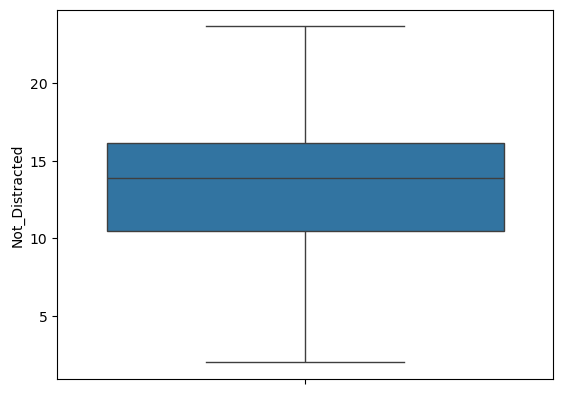

In [47]:
sns.boxplot(y='Not_Distracted',data=df)
plt.show()

In [49]:
df.head(10)

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev,Alcohol,Not_Distracted
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL,5.640,18.048
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK,4.525,16.290
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ,5.208,15.624
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR,5.824,21.056
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA,3.360,10.920
5,13.6,5.032,3.808,10.744,12.920,835.50,139.91,CO,3.808,10.744
6,10.8,4.968,3.888,9.396,8.856,1068.73,167.02,CT,3.888,9.396
7,16.2,6.156,4.860,14.094,16.038,1137.87,151.48,DE,4.860,14.094
8,5.9,2.006,1.593,5.900,5.900,1273.89,136.05,DC,1.593,5.900
9,17.9,3.759,5.191,16.468,16.826,1160.13,144.18,FL,5.191,16.468


# Analysis

## Insurance losses according to abbreviation

In [51]:
x = df.abbrev.nunique()
x

51

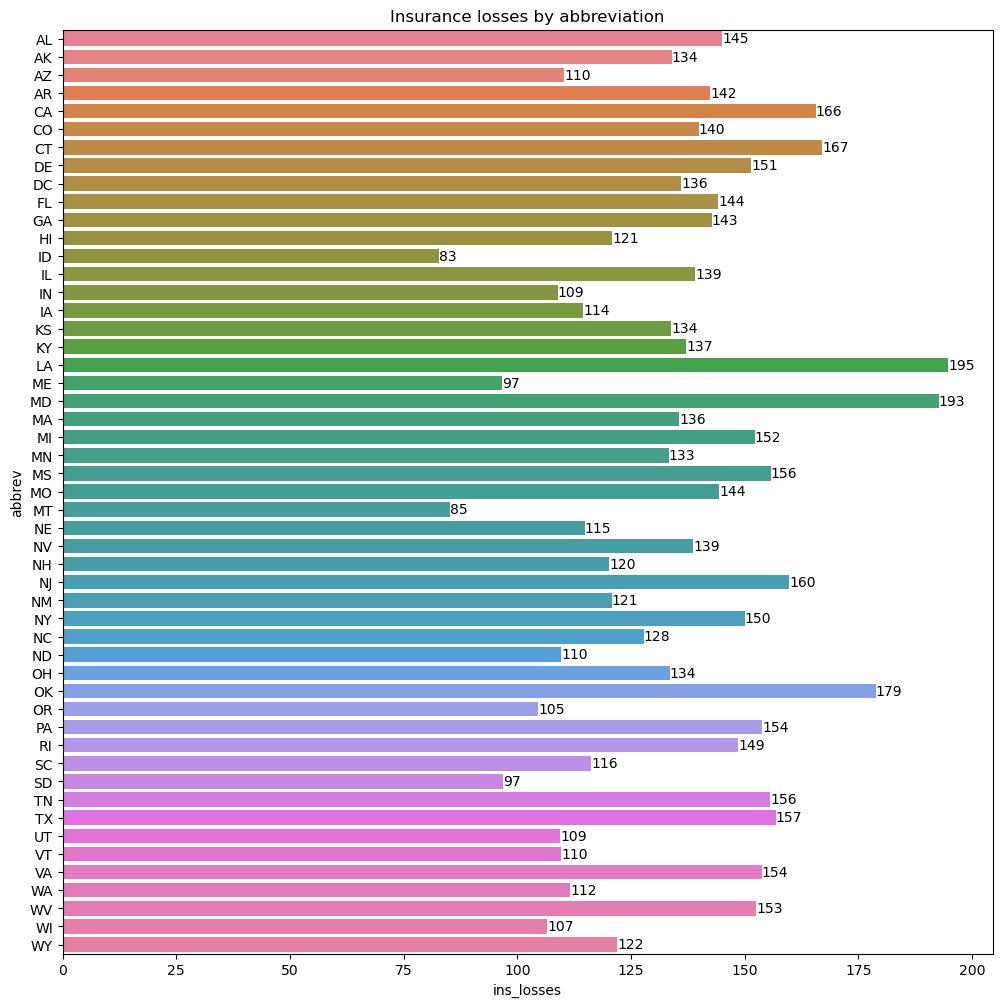

In [53]:
plt.figure(figsize=(12,12),dpi=100)
bar_graph = sns.barplot(x='ins_losses', y='abbrev', data=df, hue='abbrev', errorbar=('ci',False))
for i in bar_graph.containers:
    bar_graph.bar_label(i,fmt='%.f')
plt.title("Insurance losses by abbreviation")
plt.show()

## Relationship between total and alcohol on the basis of abbrev

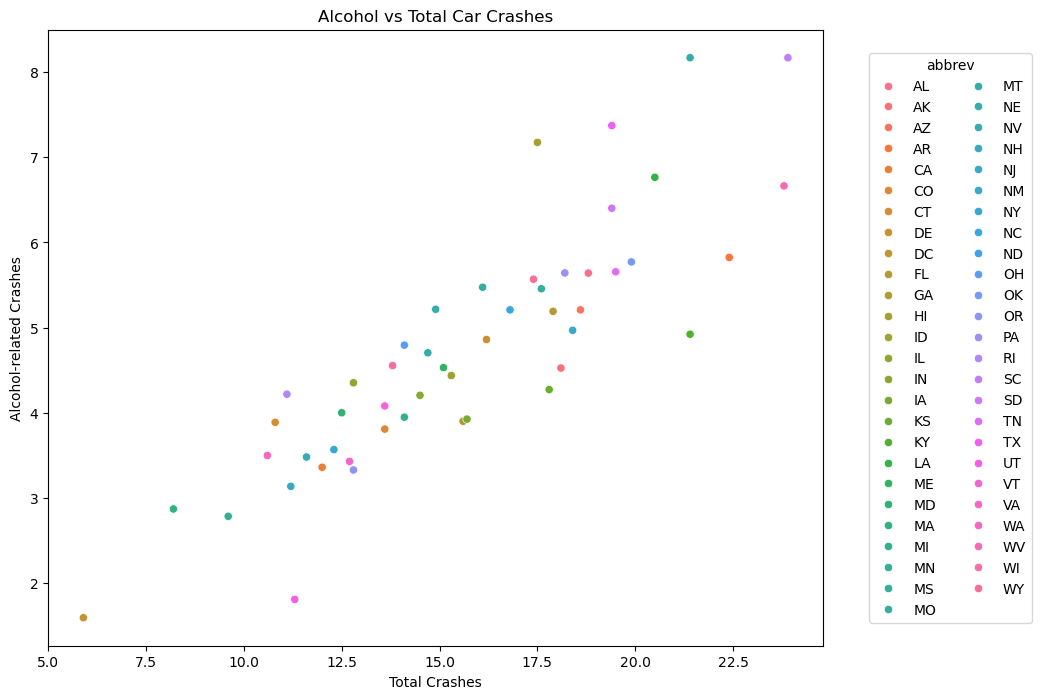

In [55]:
plt.figure(figsize=(10,8),dpi=100)
sns.scatterplot(x='total',y='Alcohol',hue='abbrev',data=df)
plt.xlabel("Total Crashes")
plt.ylabel("Alcohol-related Crashes")
plt.legend(
    loc='center left',       # anchor point of the legend
    bbox_to_anchor=(1.05, 0.5),# move it below the plot
    ncol=2,                  # number of columns (rows adjust automatically)
    title="abbrev"
)
plt.title("Alcohol vs Total Car Crashes")
plt.show()

## Distribution of Crash causes

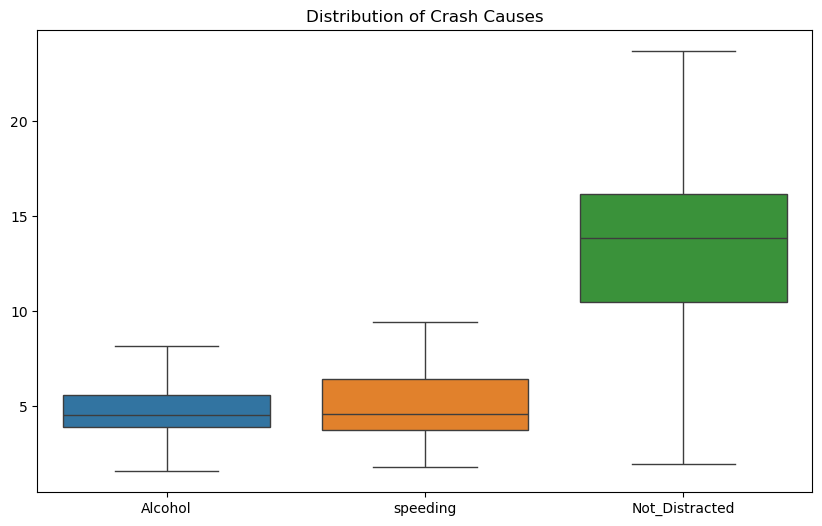

In [57]:
plt.figure(figsize=(10,6),dpi=100)
sns.boxplot(data=df[["Alcohol", "speeding", "Not_Distracted"]])
plt.title("Distribution of Crash Causes")
plt.show()


## Ratio of crash causes

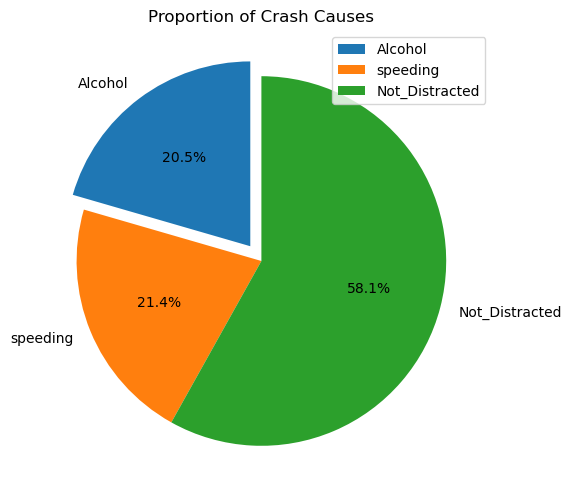

In [59]:
plt.figure(figsize=(10,6),dpi=100)
cause_totals = df[["Alcohol", "speeding", "Not_Distracted"]].sum()
explode=[0.1,0,0]
plt.pie(cause_totals, labels=cause_totals.index, autopct='%1.1f%%', startangle=90,explode=explode,shadow=False)
plt.title("Proportion of Crash Causes")
plt.legend()
plt.show()


## Correlation

In [61]:
selected_columns = ['total','speeding','Alcohol','Not_Distracted','no_previous','ins_premium','ins_losses']
data = df[selected_columns]

In [63]:
data.head()

,total,speeding,Alcohol,Not_Distracted,no_previous,ins_premium,ins_losses
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63


In [65]:
data.corr()

,total,speeding,Alcohol,Not_Distracted,no_previous,ins_premium,ins_losses
total,1.000000,0.611548,0.877480,0.830152,0.956179,-0.199702,-0.036011
speeding,0.611548,1.000000,0.701516,0.588370,0.571976,-0.077675,-0.065928
Alcohol,0.877480,0.701516,1.000000,0.737536,0.818901,-0.160617,-0.056502
Not_Distracted,0.830152,0.588370,0.737536,1.000000,0.750205,-0.175260,-0.075310
no_previous,0.956179,0.571976,0.818901,0.750205,1.000000,-0.156895,-0.006359
ins_premium,-0.199702,-0.077675,-0.160617,-0.175260,-0.156895,1.000000,0.623116
ins_losses,-0.036011,-0.065928,-0.056502,-0.075310,-0.006359,0.623116,1.000000


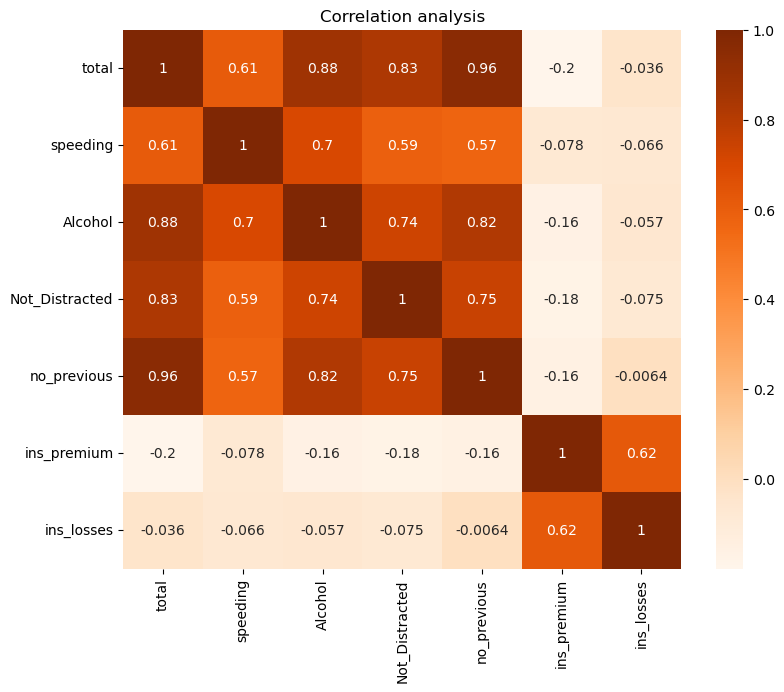

In [67]:
plt.figure(figsize=(9,7),dpi=100)
sns.heatmap(data.corr(),annot=True,cmap='Oranges')
plt.title("Correlation analysis")
plt.show()